# Line Detection with Hough Transform

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
%matplotlib inline

In [46]:
"""
Steps:

1. Canny Edge Detection
   - uses cv2 here; everything else is implemented from scratch for better understanding

2. Create and Populate the Accumulator Array in Polar Coordinates (rho, theta)
   - each edge pixel votes for every (rho, theta) line that passes through it

3. Peak Detection with Non-Max Suppression
   - threshold: keep only cells with at least `threshold` votes
   - suppress close peaks: keep a cell only if it is the maximum in its
     (rho, theta) neighborhood, so one real line doesn't produce several
     nearly identical detections

4. Draw Lines
   - convert each (rho, theta) peak back to image coordinates and draw it
"""

"\nSteps:\n\n1. Canny Edge Detection\n   - uses cv2 here; everything else is implemented from scratch for better understanding\n\n2. Create and Populate the Accumulator Array in Polar Coordinates (rho, theta)\n   - each edge pixel votes for every (rho, theta) line that passes through it\n\n3. Peak Detection with Non-Max Suppression\n   - threshold: keep only cells with at least `threshold` votes\n   - suppress close peaks: keep a cell only if it is the maximum in its\n     (rho, theta) neighborhood, so one real line doesn't produce several\n     nearly identical detections\n\n4. Draw Lines\n   - convert each (rho, theta) peak back to image coordinates and draw it\n"

### Read Image

In [137]:
from skimage import data

# Loading the sudoku image from a local path or URL used in tutorials
image = data.checkerboard()

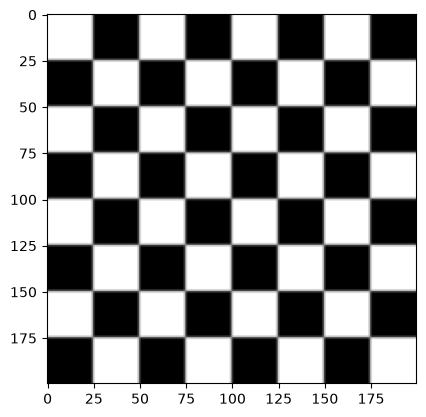

In [139]:
plt.imshow(image, cmap = 'gray')

### Step 1: Canny Edge Detection

Text(0.5, 1.0, 'canny edges')

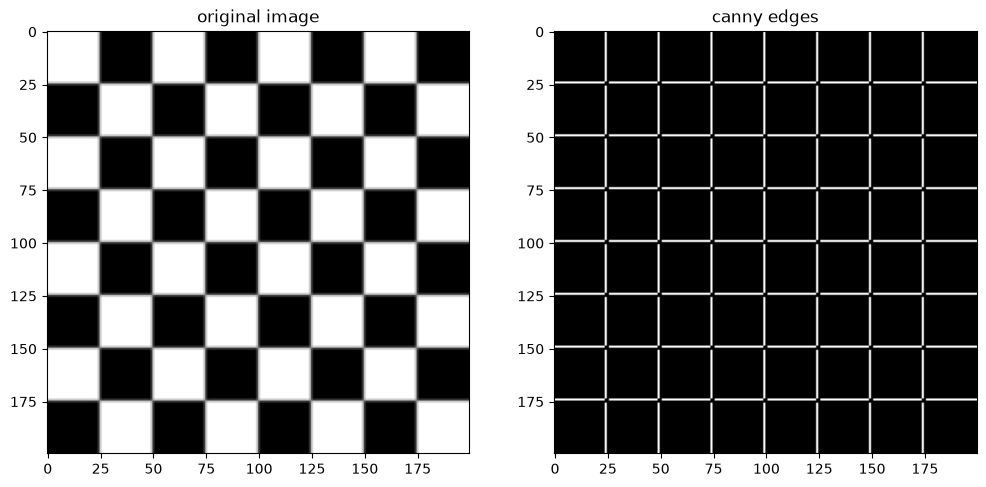

In [141]:
canny_edges = cv2.Canny(image, -1, 220, 255)

plt.figure(figsize = (12, 6))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('original image')

plt.subplot(1, 2, 2)
plt.imshow(canny_edges, cmap='gray')
plt.title('canny edges')

### Step 2: Accumulator Array

Every line in the image can be written in polar form:

$$\rho = x\cos\theta + y\sin\theta$$

where $\rho$ is the perpendicular distance from the origin (top-left corner) to the line, and $\theta \in [0, \pi)$ is the angle of that perpendicular.

Every point in image space can be reresented by a curve in the polar space. Consequently, all points from a line will create multiple sinusoid curves
in the polar space. The value of ($\rho$, $\theta \in [0, \pi)$) in the polar space at which all of these curves intersect are the ($\rho$, $\theta \in [0, \pi)$) values that define the specific lines. this is how lines are detected by hough transform, by finding these points of high intersection in polar space that represent the lines in image space.

The **accumulator** is a 2D grid of vote counts, with one row per $\rho$ value and one column per $\theta$ value. $\rho$ ranges over $[-D, D]$, where $D$ is the image diagonal, the largest possible distance.

**Voting:** each edge pixel $(x, y)$ lies on infinitely many lines. For every $\theta$, we compute the $\rho$ of the line through that pixel and add one vote to cell $(\rho, \theta)$. Each pixel therefore traces a sinusoidal curve in the accumulator.

Pixels that lie on the same straight line produce curves that all intersect at one cell, the $(\rho, \theta)$ of that line. That cell collects many votes and becomes a bright **peak**, which Step 3 detects.

In [142]:
def get_accumulator_array(edges, rho_res=1, theta_res=(np.pi/180)):
    """
    Build the Hough accumulator by letting each edge pixel vote for every
    (rho, theta) line passing through it.

    Args:
        canny_out: binary edge map (nonzero = edge pixel)
        rho_res: distance resolution in pixels
        theta_res: angle resolution in radians

    Returns:
        acc: 2D vote array of shape (num_rhos, num_thetas)
        rhos: rho value for each accumulator row
        thetas: theta value (radians) for each accumulator column
    """
    
    H, W = edges.shape

    # get distance to diagnoal of the image
    diag = int(np.ceil(np.hypot(H, W)))              

    # thetas in radians
    thetas = np.arange(0, np.pi, theta_res)          
    rhos = np.arange(-diag, diag + rho_res, rho_res) 

    # create accumulator array
    acc = np.zeros((len(rhos), len(thetas)), dtype=np.int32)

    # get cos(theta) and sin(theta) for every theta value
    cos_t, sin_t = np.cos(thetas), np.sin(thetas)
    ys, xs = np.nonzero(edges)                       # edge pixels only

    for x, y in zip(xs, ys):
        
        # get rho values for the point in image plane
        rho_vals = x * cos_t + y * sin_t
        
        # rho ranges over [-diag, diag] (negative when cos(theta) < 0), but array indices must be >= 0.
        # Adding diag shifts rho to [0, 2*diag] so -diag maps to index 0; dividing by rho_res gives the bin.
        # Without the shift, negative indices would wrap to the end of the accumulator.
        rho_idx = np.round((rho_vals + diag) / rho_res).astype(int)
        
        # one vote per theta column along the curve
        acc[rho_idx, np.arange(len(thetas))] += 1

    return acc, rhos, thetas

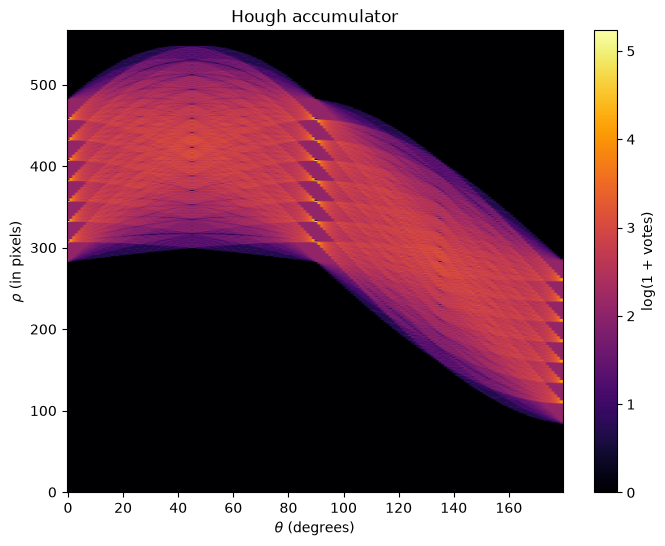

In [143]:
accum_arr, rhos, thetas = get_accumulator_array(canny_edges)

H, W = image.shape
diag = int(np.ceil(np.hypot(H, W)))              # must match the value used in my_hough_lines

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(np.log1p(accum_arr), origin='lower', aspect='auto', cmap='inferno')
fig.colorbar(im, ax=ax, label='log(1 + votes)')  # log so faint sinusoids stay visible

ax.set_xlabel(r'$\theta$ (degrees)')
ax.set_ylabel(r'$\rho$ (in pixels)')
ax.set_title('Hough accumulator')
plt.show()

### Step 3: Peak Detection and Nonmax Suppression

Lines show up as bright peaks in the accumulator. To extract them:

1. **Thresholding:** keep only cells with at least `thresh` votes, i.e. lines supported by enough edge pixels.
2. **Non-max suppression:** votes from one real line spread into neighboring $(\rho, \theta)$ cells because of discretization and noise, which would otherwise produce several nearly identical lines. A cell is kept only if it is the maximum within its `window_size × window_size` neighborhood.
3. **Convert to lines:** each surviving cell's row and column indices are mapped back to actual $(\rho, \theta)$ values using the `rhos` and `thetas` arrays, which already include the bin resolution. The lines are then sorted by vote count.

The function returns both the filtered accumulator (only the surviving peaks, useful for plotting) and the list of $(\rho, \theta)$ lines for drawing.

In [157]:
def get_detections(accum_arr, rhos, thetas, thresh=150, window_size=25):
    """
    Detect lines as peaks in the Hough accumulator using thresholding
    and non-max suppression.

    Args:
        accum_arr: 2D vote array of shape (num_rhos, num_thetas)
        rhos: rho value for each accumulator row
        thetas: theta value (radians) for each accumulator column
        thresh: minimum votes for a cell to count as a line
        window_size: neighborhood size for non-max suppression

    Returns:
        filtered_accum: accumulator with only the surviving peaks (for plotting)
        lines: list of (rho, theta) pairs, strongest first
    """
    H, W = accum_arr.shape
    rad = window_size // 2

    # candidate cells above threshold
    idxs = zip(*np.nonzero(accum_arr >= thresh))

    filtered_accum = np.zeros_like(accum_arr)

    for i, j in idxs:

        val = accum_arr[i, j]

        # neighbor bounds, clipped at the array edges
        r_start = max(0, i - rad)
        r_end = min(i + rad + 1, H)
        c_start = max(0, j - rad)
        c_end = min(j + rad + 1, W)

        nbs = accum_arr[r_start:r_end, c_start:c_end].copy()
        nbs[i - r_start, j - c_start] = 0     # exclude center (correct even at borders)

        if val >= nbs.max():
            filtered_accum[i, j] = val

    # row/col indices of surviving peaks in the accumulator
    rho_idxs, theta_idxs = np.nonzero(filtered_accum)

    # convert indices to actual (rho, theta) values
    lines = [(rhos[r], thetas[t]) for r, t in zip(rho_idxs, theta_idxs)]

    return filtered_accum, lines        

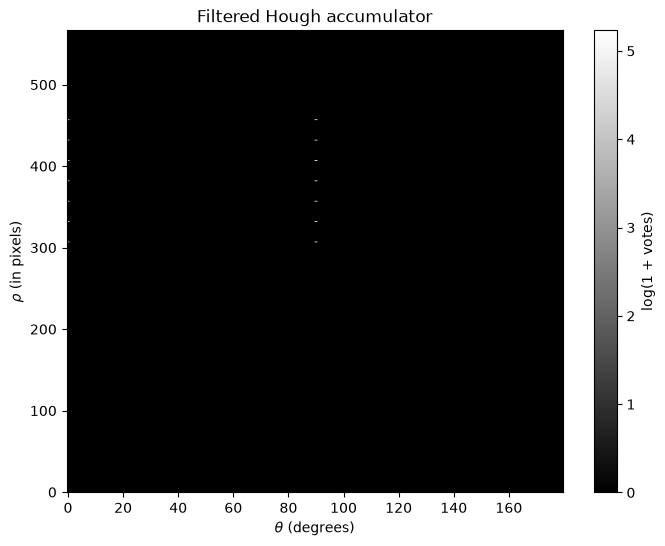

In [164]:
filt_arr, filt_lines = get_detections(accum_arr, rhos, thetas)

H, W = image.shape

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(np.log1p(filt_arr), origin='lower', aspect='auto', cmap='gray')
fig.colorbar(im, ax=ax, label='log(1 + votes)')  # log so faint sinusoids stay visible

ax.set_xlabel(r'$\theta$ (degrees)')
ax.set_ylabel(r'$\rho$ (in pixels)')
ax.set_title('Filtered Hough accumulator')
plt.show()

In [165]:
len(filt_lines)

14

### Step 4: Draw Lines

Each detected $(\rho, \theta)$ describes an infinite line, so we convert it into two endpoints to draw.

- The point on the line closest to the origin is $(x_0, y_0) = (\rho\cos\theta,\ \rho\sin\theta)$.
- The line runs perpendicular to $\theta$, in direction $(-\sin\theta,\ \cos\theta)$.
- Stepping a distance $L$ in both directions from $(x_0, y_0)$ gives the two endpoints:

$$p_{1,2} = (x_0 \mp L\sin\theta,\ \ y_0 \pm L\cos\theta)$$

$L$ is set to 1000. `cv2.line` clips any part that falls outside the image.

In [162]:
def draw_lines(image, lines, color=(0, 255, 0), thickness=2):
    """
    Draw (rho, theta) lines on a copy of the image.

    Args:
        image: grayscale or BGR image
        lines: list of (rho, theta) pairs, theta in radians
        color: BGR line color
        thickness: line thickness in pixels

    Returns:
        out: BGR image with the lines drawn
    """
    out = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR) if image.ndim == 2 else image.copy()

    for rho, theta in lines:
        a, b = np.cos(theta), np.sin(theta)
        x0, y0 = a * rho, b * rho                     # closest point to origin
        pt1 = (int(x0 - 1000 * b), int(y0 + 1000 * a))      # walk +L along the line
        pt2 = (int(x0 + 1000 * b), int(y0 - 1000 * a))      # walk -L along the line
        cv2.line(out, pt1, pt2, color, thickness)

    return out

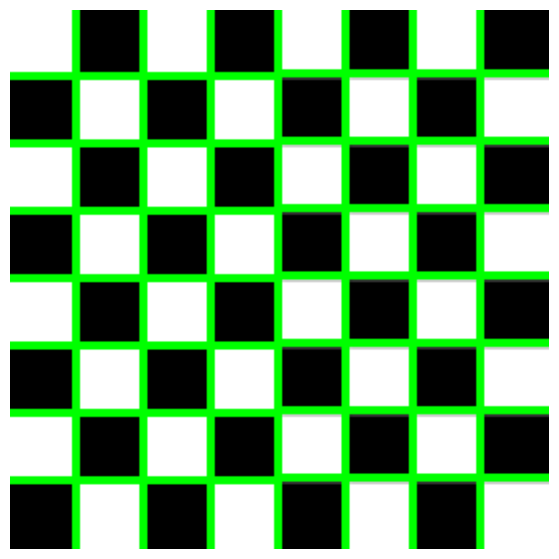

In [163]:
out = draw_lines(image, filt_lines)

plt.figure(figsize=(7, 7))
plt.imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB))    # matplotlib expects RGB
plt.axis('off')
plt.show()

# Hough line transform: key takeaways

## Core idea
- A line is parameterized as **ρ = x·cos θ + y·sin θ**
  - θ = angle of the line's **normal**/perperndicular from the origin, ρ = signed distance from origin to the line.
  - Normal form is used instead of y = mx + c because slope m → ∞ for vertical lines.
- **Point → sinusoid**: fix an edge pixel (x, y), sweep θ, and ρ(θ) traces a sinusoid.
  Collinear points' sinusoids **intersect at one (ρ, θ)**, which is the line they share.
- **Voting**: every edge pixel adds +1 to each accumulator bin along its sinusoid.
  Bins with ≥ `threshold` votes are lines.

## Accumulator
- θ ∈ [0, π): 180° is enough because negative ρ covers the other side.
- ρ ∈ [−diag, diag] where `diag = hypot(H, W)`.
- **Index offset**: `rho_idx = round((rho + diag) / rho_res)`. Adding `diag` shifts negative ρ to
  valid indices (−diag → 0). Without it, NumPy negative indexing **silently votes into the wrong bin**.
- Origin is the **top-left pixel** and y points down (same image-coordinate convention as in Canny).

## Parameters: `cv2.HoughLines(edges, rho, theta, threshold)`
- `rho = 1` → 1 px bins; `theta = np.pi/180` → 1° bins.
- **Resolution trade-off**:
  - Too coarse → imprecise lines, nearby lines merge.
  - Too fine → votes from slightly non-collinear pixels spread across bins, so no bin reaches
    `threshold` and lines are missed; bigger, slower accumulator.
  - 1 px / 1° ≈ pixel-level precision (1° shifts a line by ~1 px over ~57 px of length).
- `threshold` ≈ minimum number of edge pixels on a line. Lower gives more (and more false) lines.
- Input must be a **binary edge map** (e.g. Canny output), not a grayscale image.

## Drawing (ρ, θ) lines
- (ρ, θ) is an **infinite** line: compute two far-away points and let `cv2.line` clip them.
```python

  we can compute the vector representing (ρ, θ) with trigonometry, prep = h*sin(theta), base = h*cos(theta)
  a, b = np.cos(theta), np.sin(theta) (base, perp)         
  x0, y0 = a * rho, b * rho                                # closest point to origin
  pt1 = (int(x0 + L * (b)), int(y0 - L * a))              # walk +L along the line
  pt2 = (int(x0 - L * (b)), int(y0 + L * a))              # walk -L along the line
```
- **TODO: review trigonometry/geometry for the line walk.** There are three right triangles:
  - Triangle 1 (hypotenuse ρ, angle θ at origin) → x0 = ρ cos θ, y0 = ρ sin θ.
  - Triangle 2 & 3 (hypotenuse L, the **same θ measured from vertical** at (x0, y0)) →
    Δx = L sin θ, Δy = L cos θ. Rotating by 90° swaps sin/cos, which is why pt1/pt2 use (b, a)
    with approprite signs depending on the direcrion of the walk 
    

## OpenCV API common bugs
- `cv2.HoughLines` returns shape `(N, 1, 2)` → use `lines[:, 0]` or `lines[i][0]`.
- Returns **`None`** (not an empty array) when nothing is found, so always check `if lines is not None`.
- `cv2.HoughLinesP` (probabilistic) returns **segments** `(x1, y1, x2, y2)` directly,
  uses a random subset of points (faster), and adds `minLineLength` / `maxLineGap`.
- `polylines` is for connected point chains (polygons, contours); use `cv2.line` for Hough lines.

## questions
- **Why not y = mx + c?** Unbounded slope for vertical lines; (ρ, θ) is bounded.
- **Complexity?** O(#edge pixels × #θ bins). This is why you run it on a sparse edge map.
- **Standard vs probabilistic?** Standard gives infinite lines (ρ, θ). Probabilistic gives finite
  segments, is faster, and is usually more practical.
- **Why do detections come in clusters?** A real line spreads votes to neighbouring bins.
  Fix with NMS in the accumulator, coarser bins, or merging similar (ρ, θ).
- **Weaknesses?** Sensitive to bin size and threshold, can't tell segment extent (standard version),
  and clutter creates false peaks.